**Physics-Informed Neural Network (PINN) implementation for parameter estimation**

This notebook uses the same system and simulated measurements as `parameter_estimation.ipynb`, but estimates the unknown physical parameters with a PINN. The neural network represents the state trajectory, while trainable scalar variables represent the physical parameters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    import torch.nn.functional as F
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This PINN notebook requires PyTorch. Install it in this Jupyter kernel "
        "with: pip install torch"
    ) from exc

np.random.seed(7)
torch.manual_seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
print(f"Using device: {device}")

Using device: cpu


**Generate measurements**

The simulated plant and noisy measurement process are copied from the original notebook so the PINN is solving the same identification problem.

In [2]:
# time horizon
tf = 1.0
dt = 0.0001
t = np.arange(dt, tf + dt, dt)

# system size
n = 3

# measurement noise scale from the original notebook
RF = 1

# initial states
x0 = np.array([5.0, 1.0, 1.0], dtype=np.float32)
x = x0.copy()

# true parameters
g_true = 9.8
c_true = 1.5
m = 0.1
R_true = 6.0
L_true = 3.0

uArray = []
xArray = []
yArray = []

for i in range(int(tf / dt)):
    u = 10 * np.sin(i * dt * 40)

    uArray.append(u)
    xArray.append(x.copy())

    dx = np.array([
        x[1],
        g_true - (c_true / m) * (x[2] / x[0]) ** 2,
        -(R_true / L_true) * x[2]
    ], dtype=np.float32)

    B = np.array([0, 0, 1 / L_true], dtype=np.float32)
    x = x + dt * dx + dt * B * u
    y = x + dt * (RF ** 2) * np.random.randn(n)
    yArray.append(y.copy())

t = t.astype(np.float32)
uArray = np.array(uArray, dtype=np.float32)
xArray = np.array(xArray, dtype=np.float32)
yArray = np.array(yArray, dtype=np.float32)

print(t.shape, xArray.shape, yArray.shape)

(10000,) (10000, 3) (10000, 3)


**Prepare training points**

The simulation uses a very small time step. For PINN training, a subset of measurement points is enough for the data loss, while another subset is used for the physics residual.

In [3]:
data_stride = 20
physics_stride = 10

t_data_np = t[::data_stride, None]
y_data_np = yArray[::data_stride]

t_phys_np = t[::physics_stride, None]

t_data = torch.tensor(t_data_np, dtype=dtype, device=device)
y_data = torch.tensor(y_data_np, dtype=dtype, device=device)
t_phys_base = torch.tensor(t_phys_np, dtype=dtype, device=device)

t0 = torch.tensor([[0.0]], dtype=dtype, device=device)
x0_t = torch.tensor(x0[None, :], dtype=dtype, device=device)

state_mean = torch.tensor(y_data_np.mean(axis=0), dtype=dtype, device=device)
state_std = torch.tensor(y_data_np.std(axis=0) + 1e-6, dtype=dtype, device=device)

def u_of_t(t_tensor):
    return 10.0 * torch.sin(40.0 * t_tensor)

print(f"Data points: {len(t_data_np)}, physics points: {len(t_phys_np)}")

Data points: 500, physics points: 1000


**Define the PINN**

The network predicts normalized states. The physical parameters are stored as unconstrained trainable variables and mapped through `softplus` so the estimates stay positive.

In [4]:
class StatePINN(nn.Module):
    def __init__(self, width=64, depth=4):
        super().__init__()
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers.append(nn.Linear(width, 3))
        self.net = nn.Sequential(*layers)

        self.raw_g = nn.Parameter(torch.tensor(8.0))
        self.raw_c = nn.Parameter(torch.tensor(0.8))
        self.raw_R = nn.Parameter(torch.tensor(3.0))
        self.raw_L = nn.Parameter(torch.tensor(1.0))

    def forward(self, t_tensor):
        tau = 2.0 * t_tensor / tf - 1.0
        z = self.net(tau)
        return state_mean + state_std * z

    def parameters_positive(self):
        g = F.softplus(self.raw_g) + 1e-6
        c = F.softplus(self.raw_c) + 1e-6
        R = F.softplus(self.raw_R) + 1e-6
        L = F.softplus(self.raw_L) + 1e-6
        return g, c, R, L


def physics_residual(model, t_phys):
    t_phys = t_phys.clone().detach().requires_grad_(True)
    pred = model(t_phys)
    xpos = pred[:, 0:1]
    vel = pred[:, 1:2]
    current = pred[:, 2:3]

    dx_dt = torch.autograd.grad(xpos, t_phys, torch.ones_like(xpos), create_graph=True)[0]
    dv_dt = torch.autograd.grad(vel, t_phys, torch.ones_like(vel), create_graph=True)[0]
    di_dt = torch.autograd.grad(current, t_phys, torch.ones_like(current), create_graph=True)[0]

    g_hat, c_hat, R_hat, L_hat = model.parameters_positive()
    safe_x = torch.clamp(xpos, min=1e-3)

    r1 = dx_dt - vel
    r2 = dv_dt - (g_hat - (c_hat / m) * (current / safe_x) ** 2)
    r3 = di_dt - (-(R_hat / L_hat) * current + (1.0 / L_hat) * u_of_t(t_phys))

    return r1, r2, r3

**Train**

The loss combines measurement fit, the initial condition, and the ODE residuals.

In [5]:
model = StatePINN(width=64, depth=4).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 5000
history = {
    "loss": [], "data": [], "physics": [], "ic": [],
    "g": [], "c": [], "R": [], "L": []
}

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    y_pred = model(t_data)
    loss_data = torch.mean(((y_pred - y_data) / state_std) ** 2)

    x0_pred = model(t0)
    loss_ic = torch.mean(((x0_pred - x0_t) / state_std) ** 2)

    r1, r2, r3 = physics_residual(model, t_phys_base)
    loss_phys = torch.mean(r1 ** 2) + 0.01 * torch.mean(r2 ** 2) + torch.mean(r3 ** 2)

    loss = loss_data + 10.0 * loss_ic + loss_phys
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0 or epoch == 1:
        with torch.no_grad():
            g_hat, c_hat, R_hat, L_hat = model.parameters_positive()
            history["loss"].append(loss.item())
            history["data"].append(loss_data.item())
            history["physics"].append(loss_phys.item())
            history["ic"].append(loss_ic.item())
            history["g"].append(g_hat.item())
            history["c"].append(c_hat.item())
            history["R"].append(R_hat.item())
            history["L"].append(L_hat.item())

    if epoch % 500 == 0 or epoch == 1:
        print(
            f"epoch {epoch:5d} | loss={loss.item():.4e} | "
            f"g={g_hat.item():.3f}, c={c_hat.item():.3f}, "
            f"R={R_hat.item():.3f}, L={L_hat.item():.3f}"
        )

epoch     1 | loss=9.9138e+01 | g=7.999, c=1.172, R=3.048, L=1.314
epoch   500 | loss=1.5261e+01 | g=7.918, c=1.234, R=3.051, L=1.641
epoch  1000 | loss=7.7310e-02 | g=8.179, c=1.078, R=3.128, L=1.763
epoch  1500 | loss=3.2084e-02 | g=8.472, c=0.916, R=3.234, L=1.763
epoch  2000 | loss=2.1677e-02 | g=8.759, c=0.782, R=3.349, L=1.763
epoch  2500 | loss=1.5920e-02 | g=9.017, c=0.681, R=3.460, L=1.763
epoch  3000 | loss=1.2715e-02 | g=9.237, c=0.610, R=3.558, L=1.763
epoch  3500 | loss=1.1627e-02 | g=9.410, c=0.563, R=3.636, L=1.765
epoch  4000 | loss=1.0675e-02 | g=9.533, c=0.535, R=3.694, L=1.767
epoch  4500 | loss=1.1889e-02 | g=9.609, c=0.523, R=3.732, L=1.770
epoch  5000 | loss=9.6586e-03 | g=9.648, c=0.522, R=3.756, L=1.775


**Evaluate the learned trajectory**

True parameters:
g = 9.8000, c = 1.5000, R = 6.0000, L = 3.0000

PINN estimates:
g = 9.6481, c = 0.5221, R = 3.7562, L = 1.7750


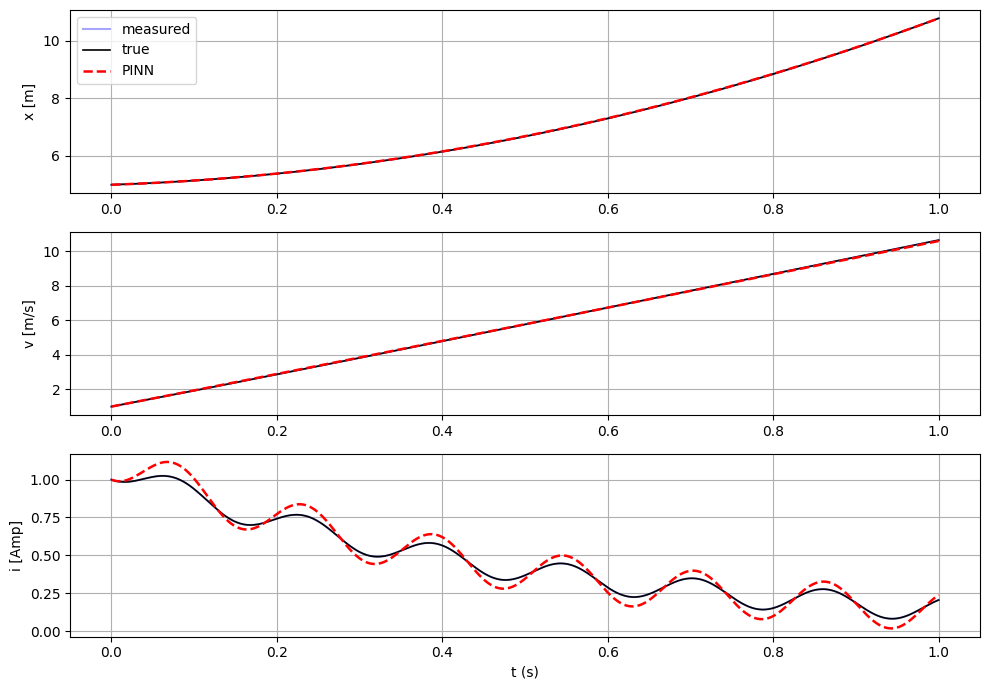

In [6]:
model.eval()
with torch.no_grad():
    t_full = torch.tensor(t[:, None], dtype=dtype, device=device)
    x_pinn = model(t_full).cpu().numpy()
    g_hat, c_hat, R_hat, L_hat = [p.item() for p in model.parameters_positive()]

print("True parameters:")
print(f"g = {g_true:.4f}, c = {c_true:.4f}, R = {R_true:.4f}, L = {L_true:.4f}")
print("\nPINN estimates:")
print(f"g = {g_hat:.4f}, c = {c_hat:.4f}, R = {R_hat:.4f}, L = {L_hat:.4f}")

plt.figure(figsize=(10, 7))

labels = ["x [m]", "v [m/s]", "i [Amp]"]
for k, label in enumerate(labels):
    plt.subplot(3, 1, k + 1)
    plt.plot(t, yArray[:, k], "b", alpha=0.35, label="measured")
    plt.plot(t, xArray[:, k], "k", linewidth=1.2, label="true")
    plt.plot(t, x_pinn[:, k], "r--", linewidth=1.8, label="PINN")
    plt.ylabel(label)
    plt.grid(True)
    if k == 0:
        plt.legend()

plt.xlabel("t (s)")
plt.tight_layout()
plt.show()

**Plot parameter convergence and final errors**

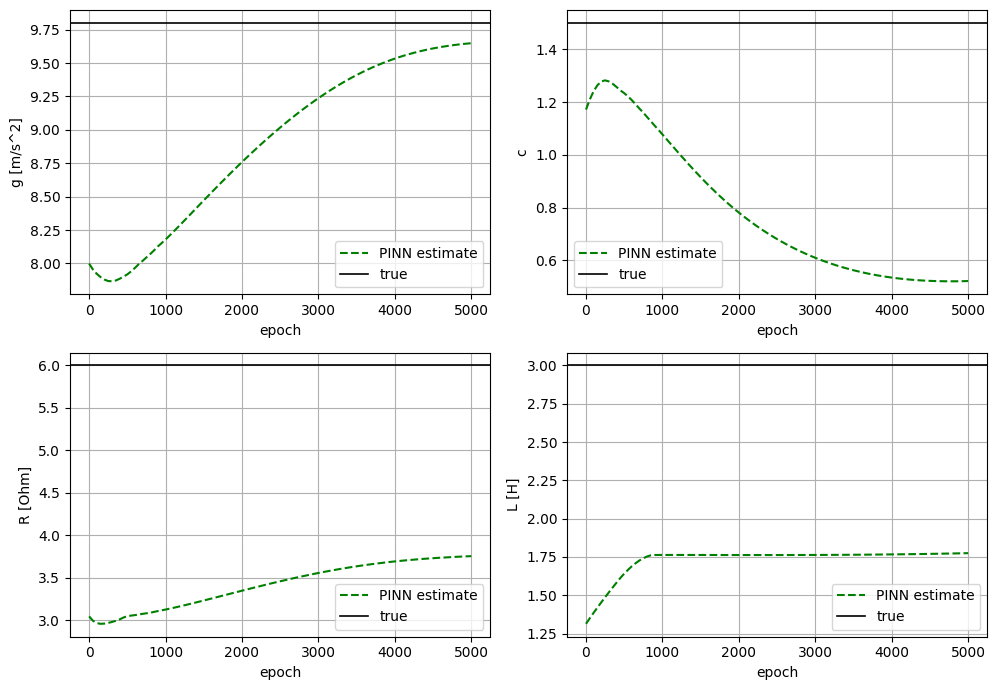

Final absolute parameter errors:
|g error| = 0.1519
|c error| = 0.9779
|R error| = 2.2438
|L error| = 1.2250


In [7]:
history_steps = np.array([1] + list(range(50, epochs + 1, 50)))

fig, axs = plt.subplots(2, 2, figsize=(10, 7))
param_info = [
    ("g", g_true, "g [m/s^2]"),
    ("c", c_true, "c"),
    ("R", R_true, "R [Ohm]"),
    ("L", L_true, "L [H]"),
]

for ax, (name, true_value, ylabel) in zip(axs.ravel(), param_info):
    ax.plot(history_steps, history[name], "g--", label="PINN estimate")
    ax.axhline(true_value, color="k", linewidth=1.2, label="true")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("epoch")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

print("Final absolute parameter errors:")
print(f"|g error| = {abs(g_true - g_hat):.4f}")
print(f"|c error| = {abs(c_true - c_hat):.4f}")
print(f"|R error| = {abs(R_true - R_hat):.4f}")
print(f"|L error| = {abs(L_true - L_hat):.4f}")

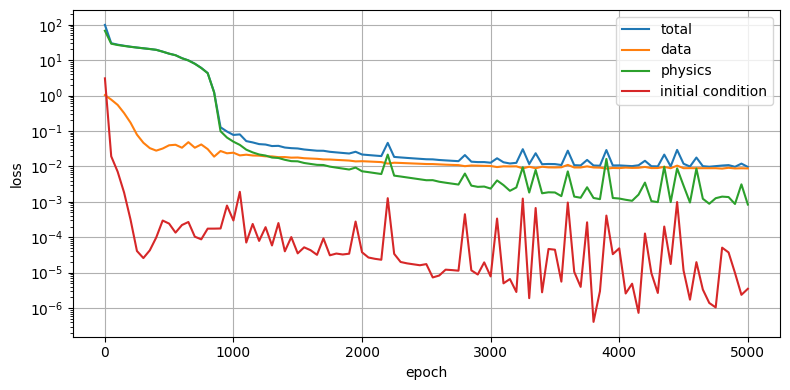

In [8]:
plt.figure(figsize=(8, 4))
plt.semilogy(history_steps, history["loss"], label="total")
plt.semilogy(history_steps, history["data"], label="data")
plt.semilogy(history_steps, history["physics"], label="physics")
plt.semilogy(history_steps, history["ic"], label="initial condition")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()